# EEVR Analysis Notebook

Clean merged notebook ordered as correlation analysis, feature visualization, text analysis, and target label analysis.


In [9]:
import os
os.chdir("/notebooks")

In [10]:
#! pip install -q pacmap
! pip install -q mapit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from mapit import MAPIT

ERROR: Could not find a version that satisfies the requirement mapit-learn (from versions: none)
ERROR: No matching distribution found for mapit-learn


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import pacmap

In [12]:
from lib.install import prepare_env
prepare_env()

Python: 3.11.7 (main, Dec  8 2023, 18:56:58) [GCC 11.4.0]
Executable: /usr/local/bin/python3

Installed versions:
numpy: 1.26.4
tensorflow: 2.18.0
tensorflow-probability: 0.25.0
tf-keras: 2.18.0
protobuf: 4.25.8
transformers: 4.46.3
datasets: 5.0.0
evaluate: 0.4.6
scikit-learn: 1.9.0
imbalanced-learn: 0.14.2
wordcloud: 1.9.6
umap-learn: 0.5.12

Environment packages OK. No installation needed.


E0000 00:00:1782175006.016500    1399 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782175006.023367    1399 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



TensorFlow check:
TensorFlow: 2.18.0
tf-keras: 2.18.0
TFP: 0.25.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### 1. Import

In [13]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### 2. Config

In [14]:
DATA_CONFIG = {
    "eda_path": "EEVR/Data_files/EDA_preprocessed_aligned.csv",
    "ppg_path": "EEVR/Data_files/PPG_preprocessed_aligned.csv",
    "text_path": "EEVR/Data_files/TEXT_preprocessed_aligned.csv",
}

#### 3. Utility functions

In [15]:
# ============================================================
# Utility: CSV read
# ============================================================

def csv_read(path):
    df = pd.read_csv(path)
    return df

## Correlation analysis


In [16]:
# ============================================================
# EDA within-group correlation analysis
# ============================================================
import numpy as np
import pandas as pd

eda_features = [
    "ku_eda", "sk_eda", "dynrange", "slope", "variance",
    "entropy", "insc", "fd_mean", "max_scr", "min_scr",
    "nSCR", "meanAmpSCR", "meanRespSCR", "sumAmpSCR", "sumRespSCR",
]

# ------------------------------------------------------------
# Read EDA data
# ------------------------------------------------------------
eda_df = csv_read(DATA_CONFIG["eda_path"])

# ------------------------------------------------------------
# Feature ID mapping: ku_eda -> E1, sk_eda -> E2, ...
# ------------------------------------------------------------
eda_feature_ids = {
    feature: f"E{i}"
    for i, feature in enumerate(eda_features, start=1)
}

# ------------------------------------------------------------
# Feature group mapping
# ------------------------------------------------------------
eda_feature_groups = {
    # Statistical and signal-level features
    "ku_eda": "Statistical and signal-level",
    "sk_eda": "Statistical and signal-level",
    "dynrange": "Statistical and signal-level",
    "slope": "Statistical and signal-level",
    "variance": "Statistical and signal-level",
    "entropy": "Statistical and signal-level",

    # Complexity and accumulated activity features
    "insc": "Complexity and accumulated activity",
    "fd_mean": "Complexity and accumulated activity",

    # Skin conductance response features
    "max_scr": "SCR features",
    "min_scr": "SCR features",
    "nSCR": "SCR features",
    "meanAmpSCR": "SCR features",
    "meanRespSCR": "SCR features",
    "sumAmpSCR": "SCR features",
    "sumRespSCR": "SCR features",
}

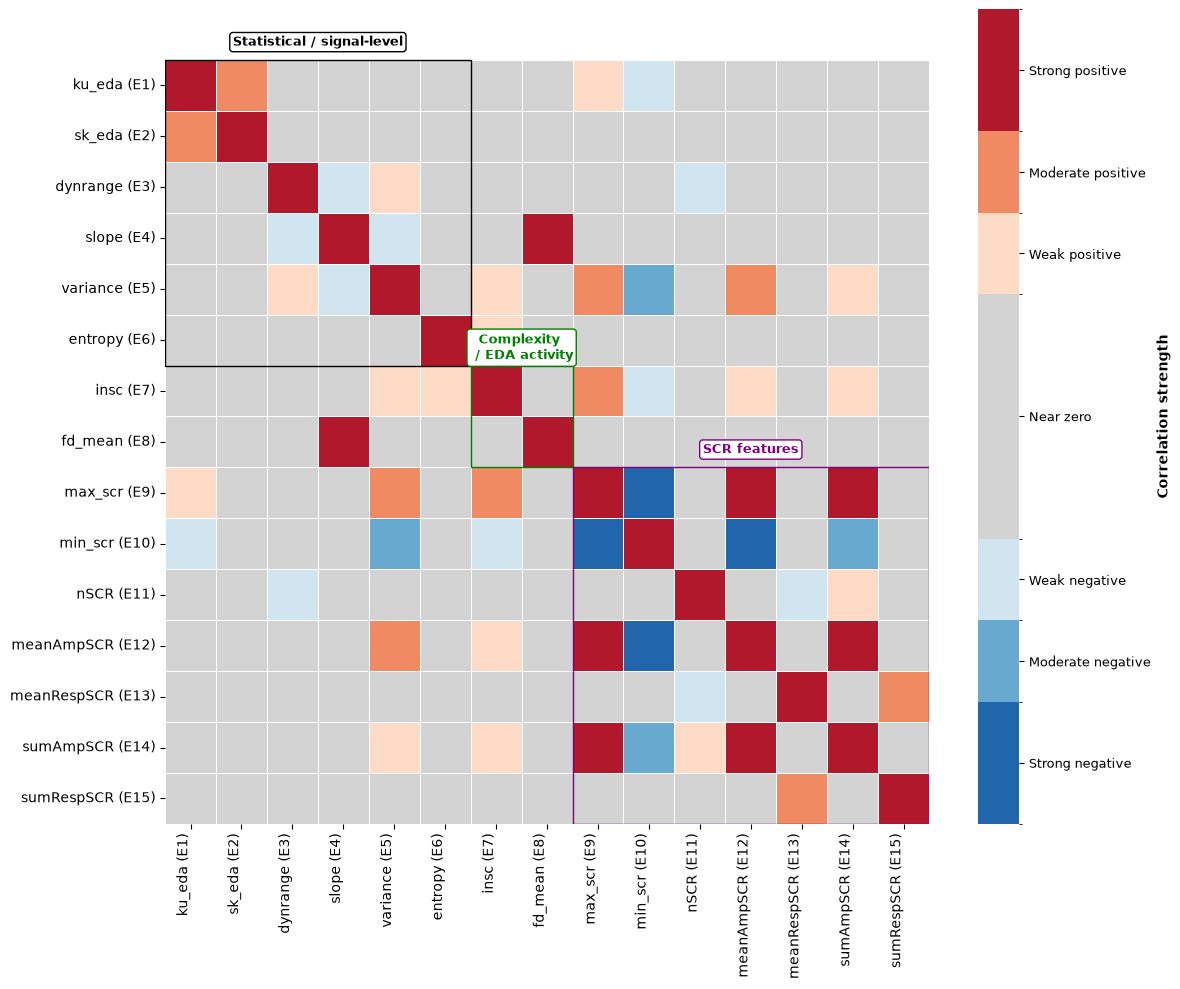

In [17]:
# ---------- EDA ----------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# Correlation matrix
# ------------------------------------------------------------
eda_corr = eda_df[eda_features].corr()

eda_feature_labels = [
    f"{feature} (E{i})"
    for i, feature in enumerate(eda_features, start=1)
]

# ------------------------------------------------------------
# Discrete correlation color setup
# ------------------------------------------------------------
threshold = 0.30

bounds = [
    -1.0,
    -0.70,
    -0.50,
    -threshold,
    threshold,
    0.50,
    0.70,
    1.0,
]

colors = [
    "#2166ac",    # strong negative
    "#67a9cf",    # moderate negative
    "#d1e5f0",    # weak negative
    "lightgray",  # near zero
    "#fddbc7",    # weak positive
    "#ef8a62",    # moderate positive
    "#b2182b",    # strong positive
]

colorbar_labels = [
    "Strong negative",
    "Moderate negative",
    "Weak negative",
    "Near zero",
    "Weak positive",
    "Moderate positive",
    "Strong positive",
]

discrete_cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, discrete_cmap.N)

tick_positions = [
    (bounds[i] + bounds[i + 1]) / 2
    for i in range(len(bounds) - 1)
]

# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    eda_corr,
    cmap=discrete_cmap,
    norm=norm,
    square=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=eda_feature_labels,
    yticklabels=eda_feature_labels,
    cbar_kws={
        "label": "Correlation strength",
        "boundaries": bounds,
        "ticks": tick_positions,
        "spacing": "proportional",
    },
)

# ------------------------------------------------------------
# Update colorbar labels
# ------------------------------------------------------------
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(colorbar_labels)
cbar.ax.tick_params(labelsize=9)
cbar.set_label(
    "Correlation strength",
    fontsize=10,
    fontweight="bold",
)

# ------------------------------------------------------------
# Draw group-level boxes and titles
# ------------------------------------------------------------
groups = [
    {
        "name": "Statistical / signal-level",
        "start": 0,
        "size": 6,
        "color": "black",
    },
    {
        "name": "Complexity \n / EDA activity",
        "start": 6,
        "size": 2,
        "color": "green",
    },
    {
        "name": "SCR features",
        "start": 8,
        "size": 7,
        "color": "purple",
    },
]

for group in groups:
    start = group["start"]
    size = group["size"]
    color = group["color"]

    rect = Rectangle(
        (start, start),
        size,
        size,
        fill=False,
        edgecolor=color,
        linewidth=1,
    )
    ax.add_patch(rect)

    ax.text(
        start + size/2,
        start - 0.35,
        group["name"],
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=color,
        bbox=dict(
            facecolor="white",
            edgecolor=color,
            boxstyle="round,pad=0.25",
            linewidth=1,
        ),
        clip_on=False,
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_ylim(len(eda_features), -1.0)
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
ppg_df = csv_read(DATA_CONFIG["ppg_path"])

ppg_features = ["BPM", "IBI", "PPG_Rate_Mean", "HRV_MedianNN", "HRV_Prc20NN", "HRV_MinNN", "HRV_HTI", "HRV_TINN", "HRV_LF",
                "HRV_VHF", "HRV_LFn", "HRV_HFn", "HRV_LnHF", "HRV_SD1SD2", "HRV_CVI", "HRV_PSS", "HRV_PAS", "HRV_PI",
                "HRV_C1d", "HRV_C1a", "HRV_DFA_alpha1", "HRV_MFDFA_alpha1_Width", "HRV_MFDFA_alpha1_Peak", "HRV_MFDFA_alpha1_Mean",
                "HRV_MFDFA_alpha1_Max", "HRV_MFDFA_alpha1_Delta", "HRV_MFDFA_alpha1_Asymmetry", "HRV_ApEn", "HRV_ShanEn",
                "HRV_FuzzyEn", "HRV_MSEn", "HRV_CMSEn", "HRV_RCMSEn", "HRV_CD", "HRV_HFD", "HRV_KFD", "HRV_LZC"]


identifiers = [
    "Participant ID",
    "Video ID",
    "arousal_category",
    "valence_category",
    "taskwiselabel",
]

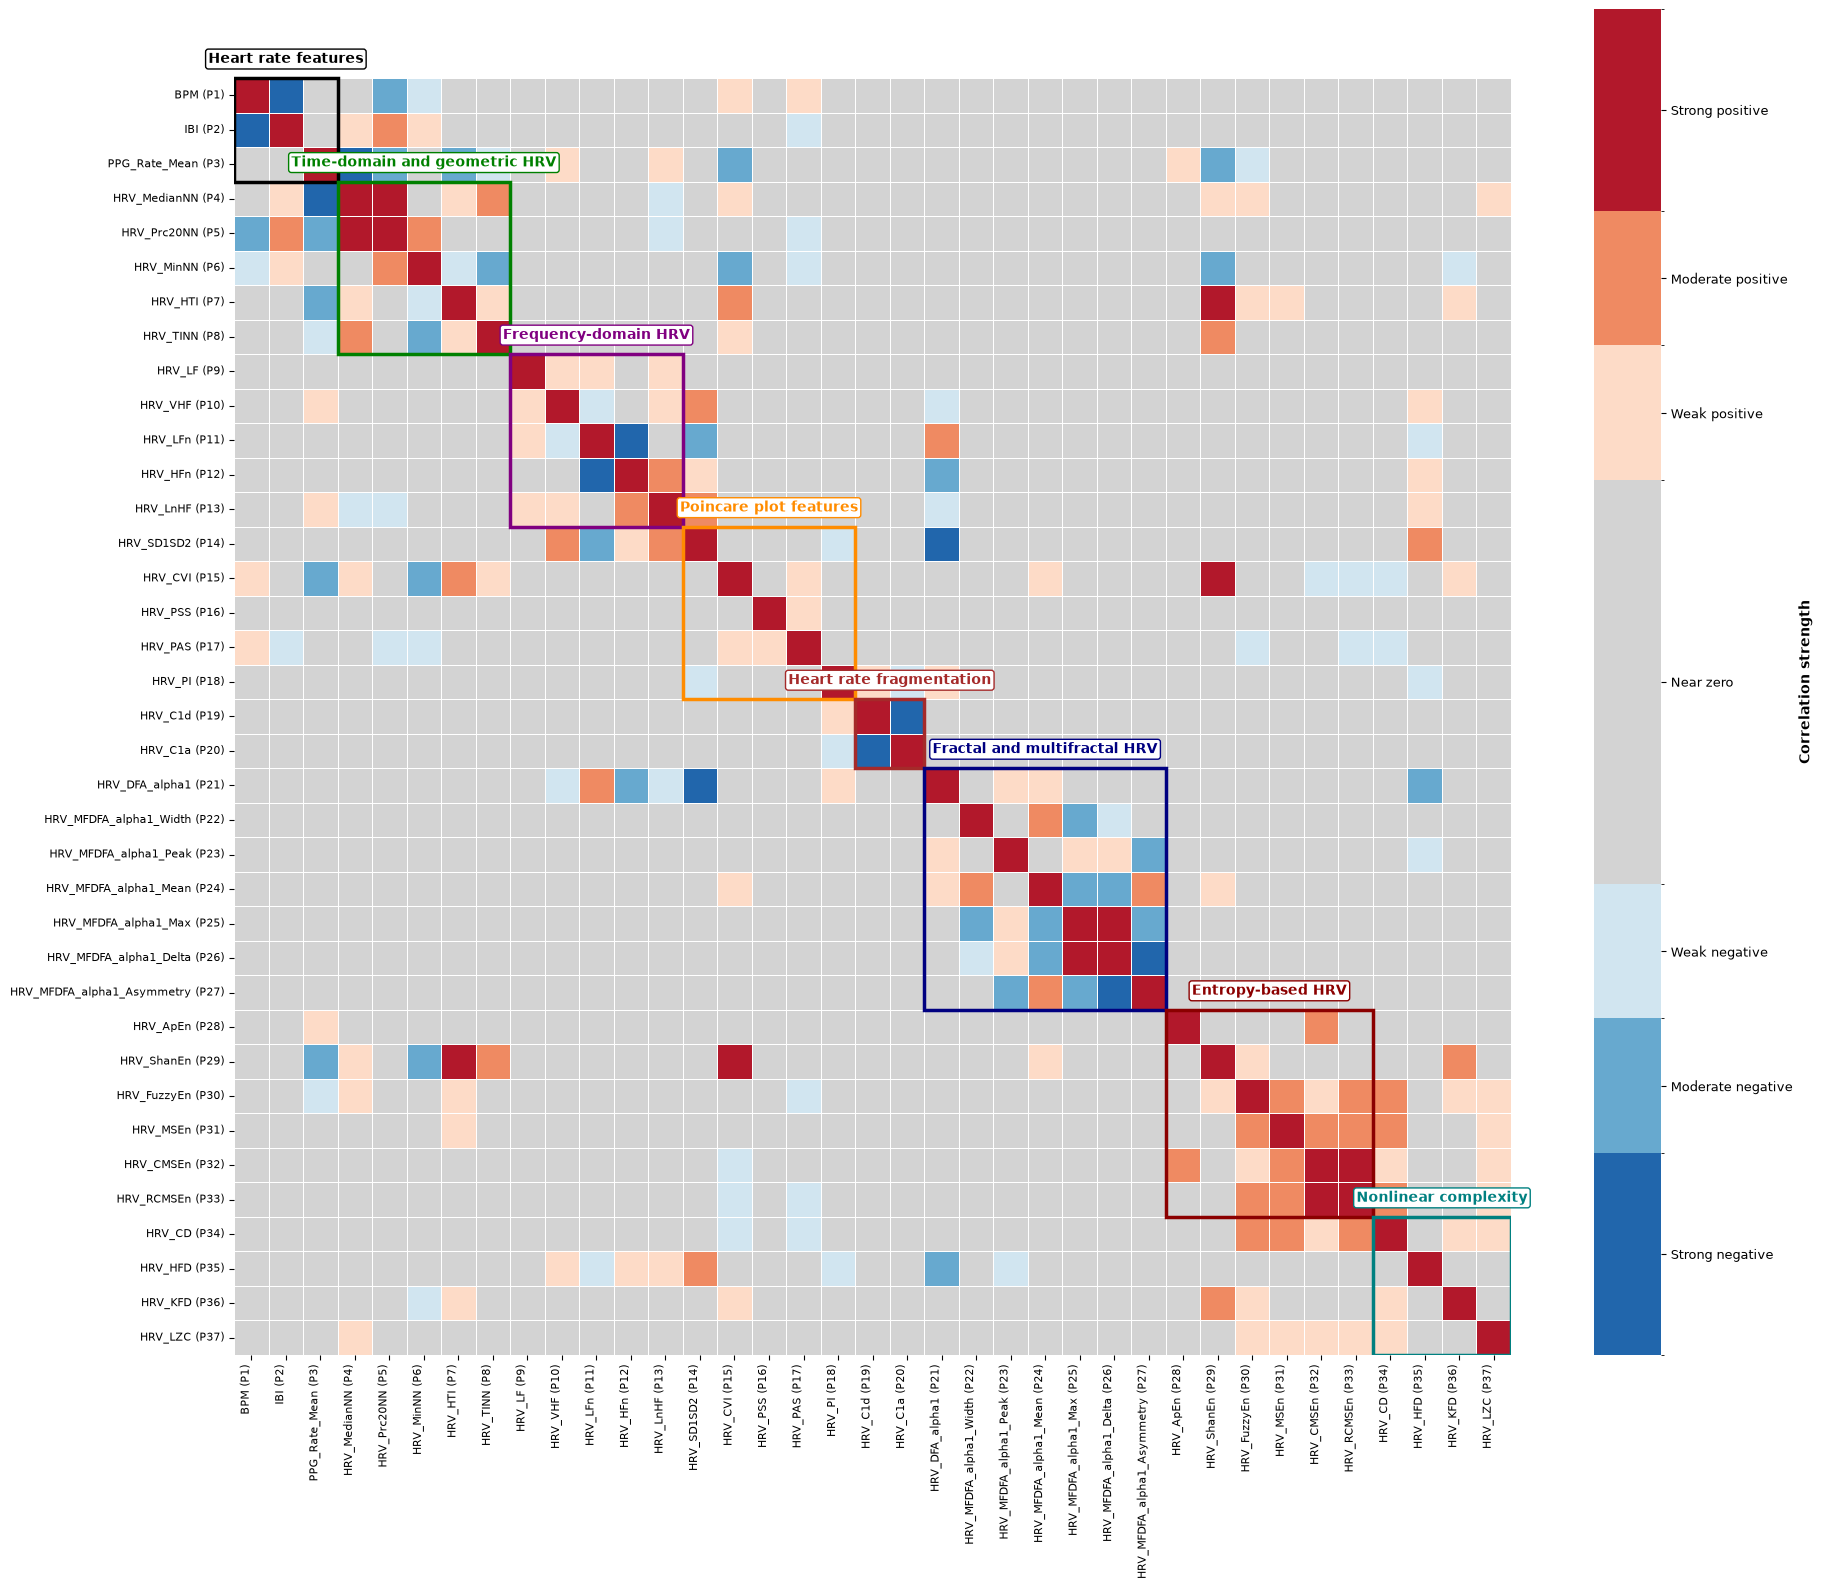

In [19]:
# ---------- PPG ----------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# Read PPG data
# ------------------------------------------------------------
ppg_df = csv_read(DATA_CONFIG["ppg_path"])

ppg_features = [
    "BPM", "IBI", "PPG_Rate_Mean",
    "HRV_MedianNN", "HRV_Prc20NN", "HRV_MinNN", "HRV_HTI", "HRV_TINN",
    "HRV_LF", "HRV_VHF", "HRV_LFn", "HRV_HFn", "HRV_LnHF",
    "HRV_SD1SD2", "HRV_CVI", "HRV_PSS", "HRV_PAS", "HRV_PI",
    "HRV_C1d", "HRV_C1a",
    "HRV_DFA_alpha1", "HRV_MFDFA_alpha1_Width", "HRV_MFDFA_alpha1_Peak",
    "HRV_MFDFA_alpha1_Mean", "HRV_MFDFA_alpha1_Max",
    "HRV_MFDFA_alpha1_Delta", "HRV_MFDFA_alpha1_Asymmetry",
    "HRV_ApEn", "HRV_ShanEn", "HRV_FuzzyEn", "HRV_MSEn",
    "HRV_CMSEn", "HRV_RCMSEn",
    "HRV_CD", "HRV_HFD", "HRV_KFD", "HRV_LZC"
]

# ------------------------------------------------------------
# PPG feature labels: BPM -> P1, IBI -> P2, ...
# ------------------------------------------------------------
ppg_feature_labels = [
    f"{feature} (P{i})"
    for i, feature in enumerate(ppg_features, start=1)
]

# ------------------------------------------------------------
# Correlation matrix
# ------------------------------------------------------------
ppg_corr = ppg_df[ppg_features].corr()

# ------------------------------------------------------------
# Discrete correlation color setup
# ------------------------------------------------------------
threshold = 0.30

bounds = [
    -1.0,
    -0.70,
    -0.50,
    -threshold,
    threshold,
    0.50,
    0.70,
    1.0,
]

colors = [
    "#2166ac",    # strong negative
    "#67a9cf",    # moderate negative
    "#d1e5f0",    # weak negative
    "lightgray",  # near zero
    "#fddbc7",    # weak positive
    "#ef8a62",    # moderate positive
    "#b2182b",    # strong positive
]

colorbar_labels = [
    "Strong negative",
    "Moderate negative",
    "Weak negative",
    "Near zero",
    "Weak positive",
    "Moderate positive",
    "Strong positive",
]

discrete_cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, discrete_cmap.N)

tick_positions = [
    (bounds[i] + bounds[i + 1]) / 2
    for i in range(len(bounds) - 1)
]

# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------
plt.figure(figsize=(19, 16))

ax = sns.heatmap(
    ppg_corr,
    cmap=discrete_cmap,
    norm=norm,
    square=True,
    linewidths=0.4,
    linecolor="white",
    xticklabels=ppg_feature_labels,
    yticklabels=ppg_feature_labels,
    cbar_kws={
        "label": "Correlation strength",
        "boundaries": bounds,
        "ticks": tick_positions,
        "spacing": "proportional",
    },
)

# ------------------------------------------------------------
# Update colorbar labels
# ------------------------------------------------------------
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(colorbar_labels)
cbar.ax.tick_params(labelsize=9)
cbar.set_label(
    "Correlation strength",
    fontsize=10,
    fontweight="bold",
)

# ------------------------------------------------------------
# Draw group-level boxes and titles
# Groups follow the PPG feature table:
#
# P1-P3   Heart rate features
# P4-P8   Time-domain and geometric HRV features
# P9-P13  Frequency-domain HRV features
# P14-P18 Poincare plot features
# P19-P20 Heart rate fragmentation features
# P21-P27 Fractal and multifractal HRV features
# P28-P33 Entropy-based HRV features
# P34-P37 Nonlinear complexity features
# ------------------------------------------------------------
groups = [
    {
        "name": "Heart rate features",
        "start": 0,
        "size": 3,
        "color": "black",
    },
    {
        "name": "Time-domain and geometric HRV",
        "start": 3,
        "size": 5,
        "color": "green",
    },
    {
        "name": "Frequency-domain HRV",
        "start": 8,
        "size": 5,
        "color": "purple",
    },
    {
        "name": "Poincare plot features",
        "start": 13,
        "size": 5,
        "color": "darkorange",
    },
    {
        "name": "Heart rate fragmentation",
        "start": 18,
        "size": 2,
        "color": "brown",
    },
    {
        "name": "Fractal and multifractal HRV",
        "start": 20,
        "size": 7,
        "color": "navy",
    },
    {
        "name": "Entropy-based HRV",
        "start": 27,
        "size": 6,
        "color": "darkred",
    },
    {
        "name": "Nonlinear complexity",
        "start": 33,
        "size": 4,
        "color": "teal",
    },
]

for group in groups:
    start = group["start"]
    size = group["size"]
    color = group["color"]

    # Group box on the diagonal
    rect = Rectangle(
        (start, start),
        size,
        size,
        fill=False,
        edgecolor=color,
        linewidth=2.5,
    )
    ax.add_patch(rect)

    # Group title above the diagonal box
    ax.text(
        start + size / 2,
        start - 0.55,
        group["name"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=color,
        rotation=0,
        bbox=dict(
            facecolor="white",
            edgecolor=color,
            boxstyle="round,pad=0.20",
            linewidth=1,
        ),
        clip_on=False,
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_ylim(len(ppg_features), -2.0)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

## Feature visualization


In [20]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [21]:
eda_features = [
    "ku_eda", "sk_eda", "dynrange", "slope", "variance",
    "entropy", "insc", "fd_mean", "max_scr", "min_scr",
    "nSCR", "meanAmpSCR", "meanRespSCR", "sumAmpSCR", "sumRespSCR",
]

identifiers = [
    "Participant ID",
    "Video ID",
    "arousal_category",
    "valence_category",
    "taskwiselabel",
]


eda_df = csv_read(DATA_CONFIG["eda_path"])

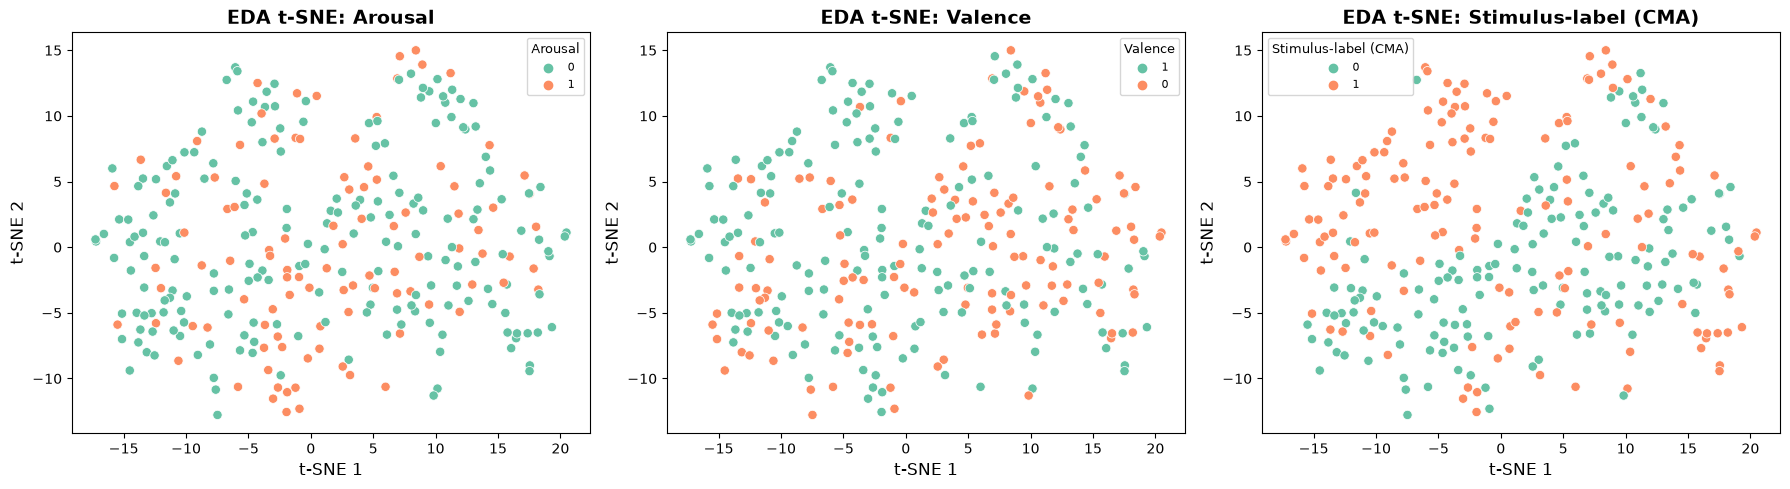

In [22]:
# ============================================================
# t-SNE visualization for EDA features
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

label_cols = ["arousal_category", "valence_category", "taskwiselabel"]
label_titles = ["Arousal", "Valence", "Stimulus-label (CMA)"]

# ============================================================
# t-SNE on EDA features
# ============================================================
X = eda_df[eda_features].copy()


tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    max_iter=5000,
    n_iter_without_progress=500
)


X_tsne = tsne_model.fit_transform(X)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
})

# Add label columns
for col in label_cols:
    tsne_df[col] = eda_df[col].astype(str).values

# ============================================================
# Plot t-SNE results
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, ttl in zip(axes, label_cols, label_titles):

    sns.scatterplot(
        data=tsne_df,
        x="TSNE1",
        y="TSNE2",
        hue=col,
        palette="Set2",
        ax=ax,
        s=45
    )

    ax.set_title(f"EDA t-SNE: {ttl}", fontsize=14, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=12)
    ax.set_ylabel("t-SNE 2", fontsize=12)
    ax.legend(title=ttl, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

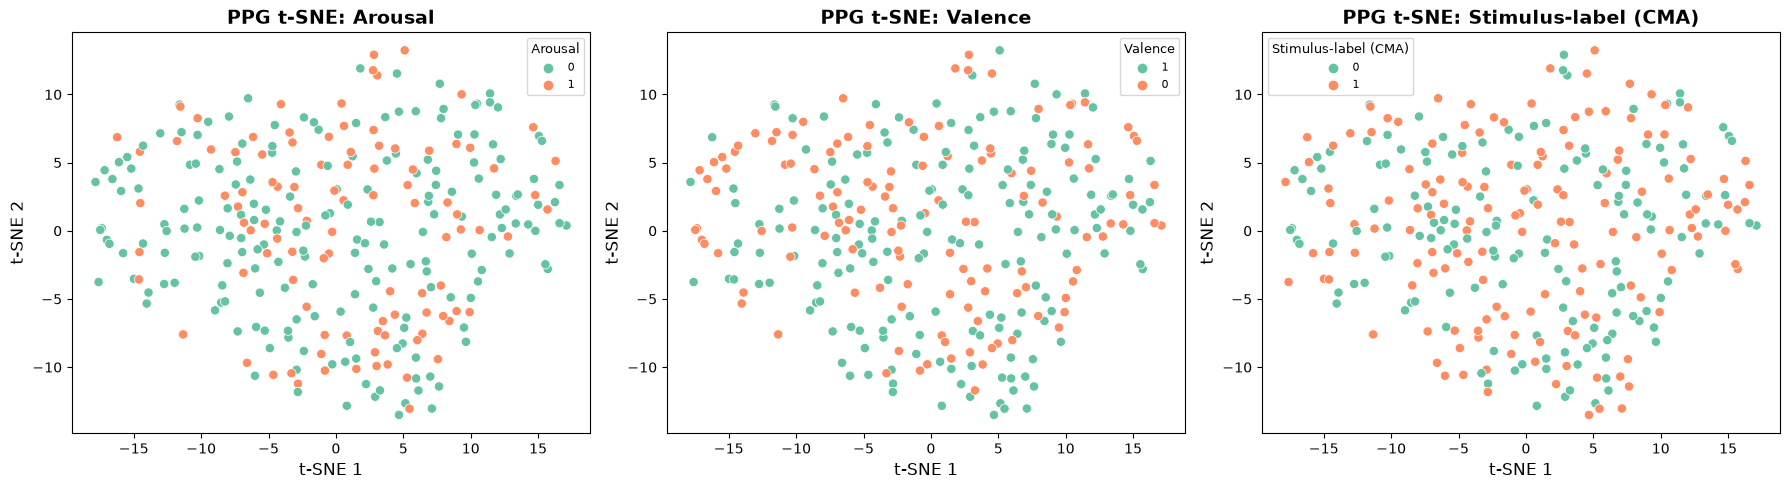

In [23]:
# ============================================================
# t-SNE visualization for PPG features
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

label_cols = ["arousal_category", "valence_category", "taskwiselabel"]
label_titles = ["Arousal", "Valence", "Stimulus-label (CMA)"]


# ============================================================
# t-SNE on PPG features
# ============================================================
X = ppg_df[ppg_features].copy()

tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne_model.fit_transform(X)


# ============================================================
# Create t-SNE dataframe
# ============================================================
tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
})

for col in label_cols:
    tsne_df[col] = ppg_df[col].astype(str).values


# ============================================================
# Plot t-SNE results
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, ttl in zip(axes, label_cols, label_titles):

    sns.scatterplot(
        data=tsne_df,
        x="TSNE1",
        y="TSNE2",
        hue=col,
        palette="Set2",
        ax=ax,
        s=45
    )

    ax.set_title(f"PPG t-SNE: {ttl}", fontsize=14, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=12)
    ax.set_ylabel("t-SNE 2", fontsize=12)
    ax.legend(title=ttl, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Load text data
# ============================================================
text_df = csv_read(DATA_CONFIG["text_path"])

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


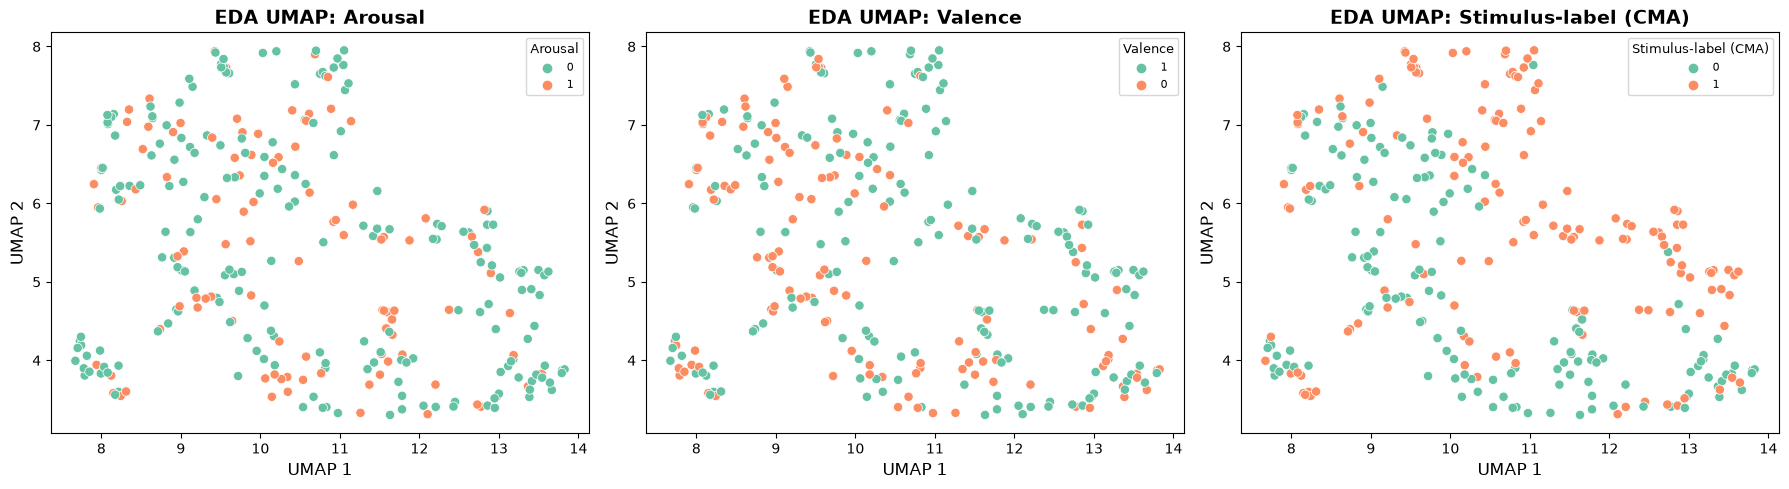

In [25]:
# ============================================================
# UMAP visualization for EDA features
# ============================================================
! pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from umap import UMAP

label_cols = ["arousal_category", "valence_category", "taskwiselabel"]
label_titles = ["Arousal", "Valence", "Stimulus-label (CMA)"]

# ============================================================
# UMAP on EDA features
# ============================================================
X = eda_df[eda_features].copy()


umap_model = UMAP(
    n_components=2,
    n_neighbors=30,        # larger value gives more global structure
    min_dist=0.00,         # smaller value makes clusters tighter
    metric="cosine",       # often better for high-dimensional feature patterns
    spread=1.0,
    random_state=42
)

X_umap = umap_model.fit_transform(X)

umap_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
})

# Add label columns
for col in label_cols:
    umap_df[col] = eda_df[col].astype(str).values

# ============================================================
# Plot UMAP results
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, ttl in zip(axes, label_cols, label_titles):

    sns.scatterplot(
        data=umap_df,
        x="UMAP1",
        y="UMAP2",
        hue=col,
        palette="Set2",
        ax=ax,
        s=45
    )

    ax.set_title(f"EDA UMAP: {ttl}", fontsize=14, fontweight="bold")
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.legend(title=ttl, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

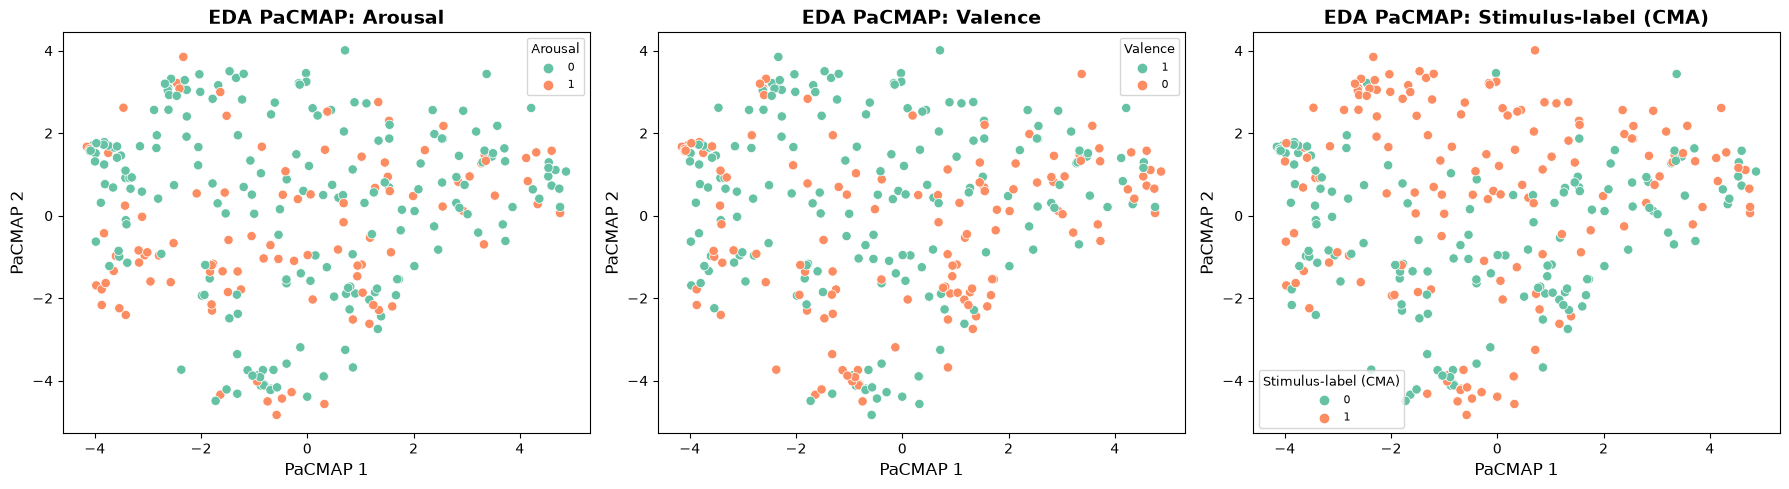

In [26]:
# ============================================================
# PaCMAP visualization for EDA features
# ============================================================


# ============================================================
# Labels
# ============================================================
label_cols   = ["arousal_category", "valence_category", "taskwiselabel"]
label_titles = ["Arousal", "Valence", "Stimulus-label (CMA)"]

# ============================================================
# PaCMAP on EDA features
# ============================================================
X = eda_df[eda_features].copy()

# PaCMAP usually works better with scaled features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pacmap_model = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=30,      # similar role as UMAP n_neighbors
    MN_ratio=0.5,        # controls mid-near pairs
    FP_ratio=2.0,        # controls further pairs
    distance="euclidean",
    random_state=42
)

X_pacmap = pacmap_model.fit_transform(X_scaled, init="pca")

pacmap_df = pd.DataFrame({
    "PaCMAP1": X_pacmap[:, 0],
    "PaCMAP2": X_pacmap[:, 1],
})

# Add label columns
for col in label_cols:
    pacmap_df[col] = eda_df[col].astype(str).values

# ============================================================
# Plot PaCMAP results
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, ttl in zip(axes, label_cols, label_titles):

    sns.scatterplot(
        data=pacmap_df,
        x="PaCMAP1",
        y="PaCMAP2",
        hue=col,
        palette="Set2",
        ax=ax,
        s=45
    )

    ax.set_title(f"EDA PaCMAP: {ttl}", fontsize=14, fontweight="bold")
    ax.set_xlabel("PaCMAP 1", fontsize=12)
    ax.set_ylabel("PaCMAP 2", fontsize=12)
    ax.legend(title=ttl, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


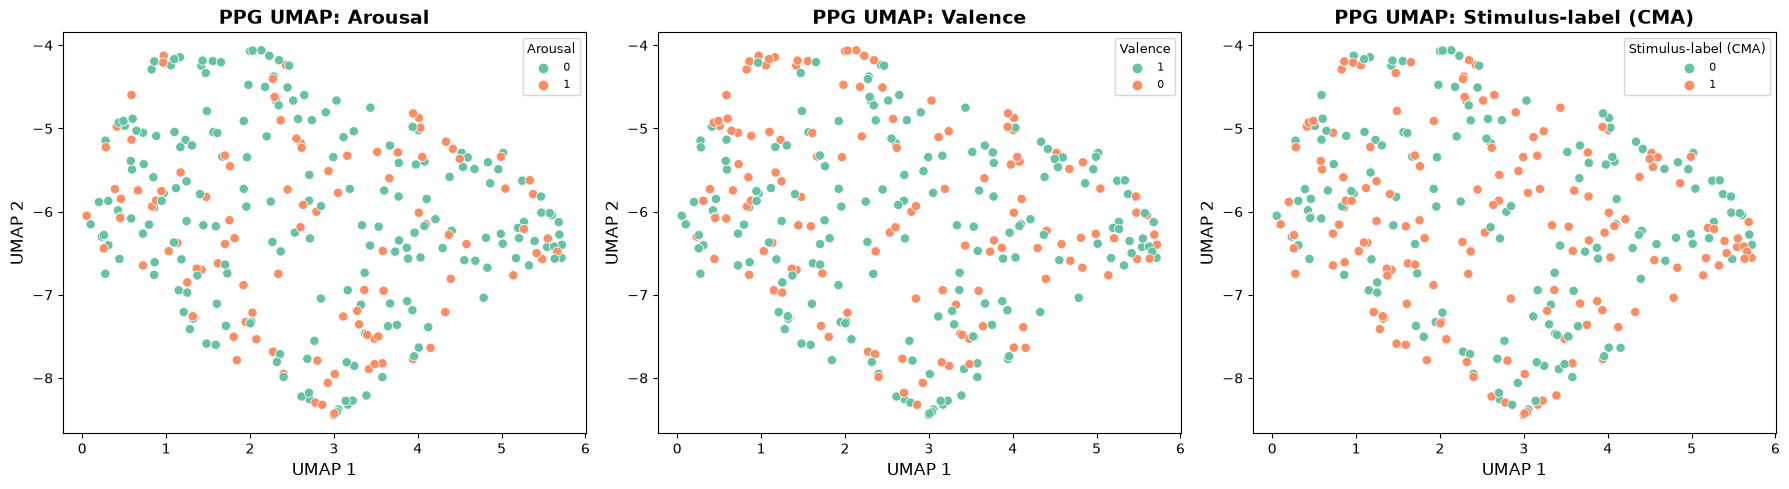

In [27]:
# ============================================================
# UMAP visualization for PPG features
# ============================================================
! pip install -q umap-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from umap import UMAP

label_cols = ["arousal_category", "valence_category", "taskwiselabel"]
label_titles = ["Arousal", "Valence", "Stimulus-label (CMA)"]

# ============================================================
# UMAP on PPG features
# ============================================================
X = ppg_df[ppg_features].copy()

umap_model = UMAP(
    n_components=2,
    n_neighbors=30,        # larger value gives more global structure
    min_dist=0.00,         # smaller value makes clusters tighter
    metric="cosine",       # often better for high-dimensional feature patterns
    spread=1.0,
    random_state=42
)


X_umap = umap_model.fit_transform(X)

umap_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
})

# Add label columns
for col in label_cols:
    umap_df[col] = ppg_df[col].astype(str).values

# ============================================================
# Plot UMAP results
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, ttl in zip(axes, label_cols, label_titles):

    sns.scatterplot(
        data=umap_df,
        x="UMAP1",
        y="UMAP2",
        hue=col,
        palette="Set2",
        ax=ax,
        s=45
    )

    ax.set_title(f"PPG UMAP: {ttl}", fontsize=14, fontweight="bold")
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.legend(title=ttl, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

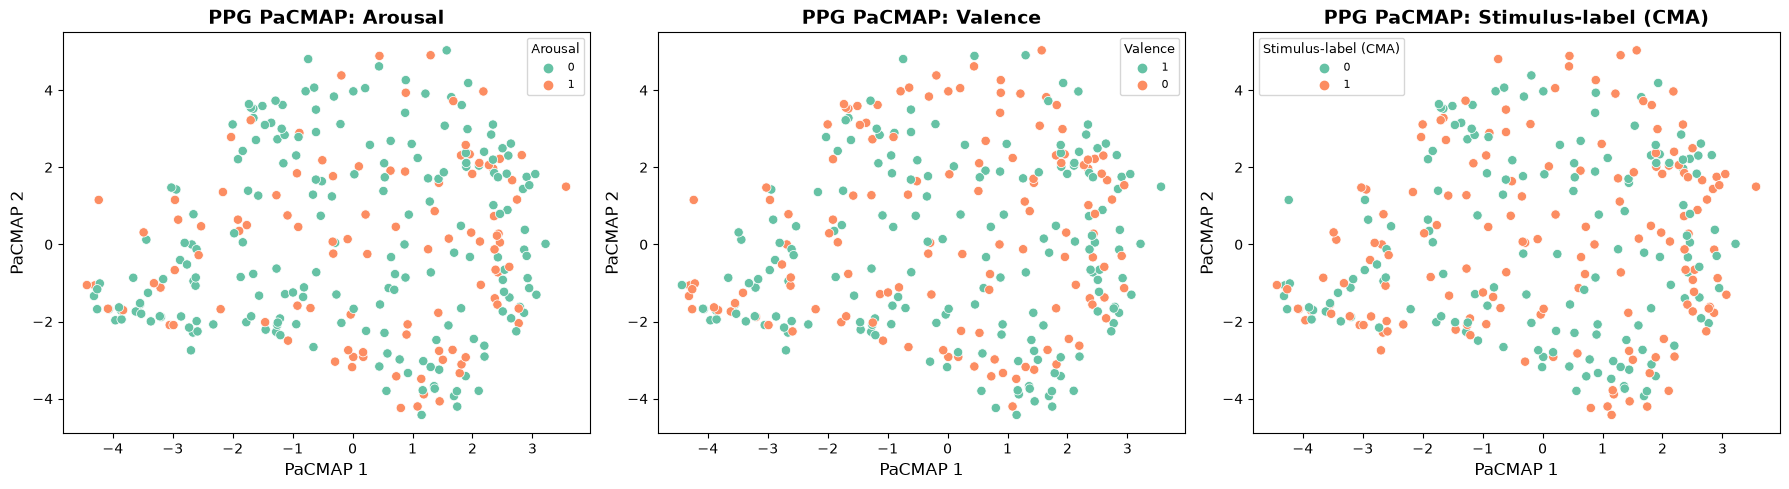

In [33]:
# ============================================================
# PaCMAP visualization for PPG features
# ============================================================


label_cols = ["arousal_category", "valence_category", "taskwiselabel"]
label_titles = ["Arousal", "Valence", "Stimulus-label (CMA)"]

# ============================================================
# PaCMAP on PPG features
# ============================================================
X = ppg_df[ppg_features].copy()

# PaCMAP generally works better with scaled features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pacmap_model = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=30,
    MN_ratio=0.5,
    FP_ratio=2.0,
    distance="euclidean",
    random_state=42
)

X_pacmap = pacmap_model.fit_transform(X_scaled, init="pca")

pacmap_df = pd.DataFrame({
    "PaCMAP1": X_pacmap[:, 0],
    "PaCMAP2": X_pacmap[:, 1],
})

# Add label columns
for col in label_cols:
    pacmap_df[col] = ppg_df[col].astype(str).values

# ============================================================
# Plot PaCMAP results
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, ttl in zip(axes, label_cols, label_titles):

    sns.scatterplot(
        data=pacmap_df,
        x="PaCMAP1",
        y="PaCMAP2",
        hue=col,
        palette="Set2",
        ax=ax,
        s=45
    )

    ax.set_title(f"PPG PaCMAP: {ttl}", fontsize=14, fontweight="bold")
    ax.set_xlabel("PaCMAP 1", fontsize=12)
    ax.set_ylabel("PaCMAP 2", fontsize=12)
    ax.legend(title=ttl, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

## Text analysis


In [28]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [29]:
text_df = csv_read(DATA_CONFIG["text_path"])

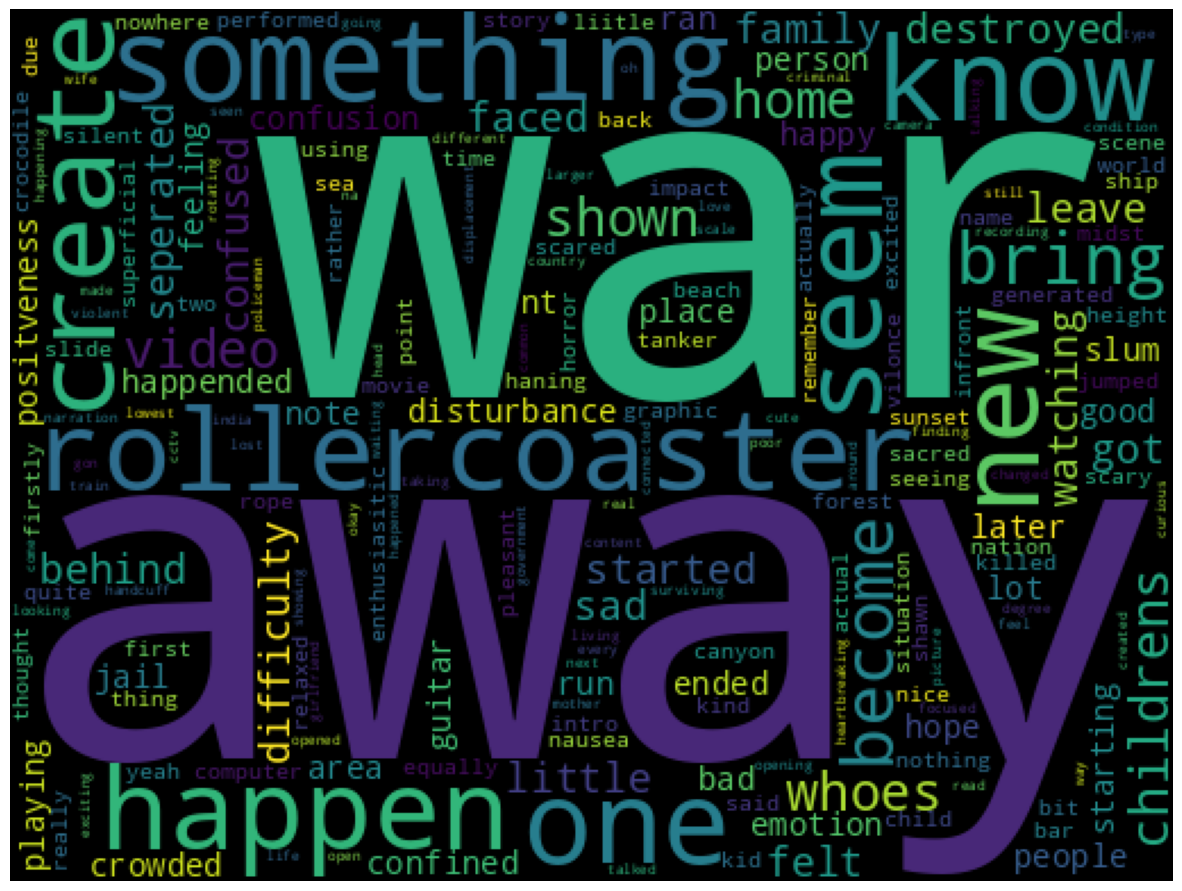

In [30]:
# ============================================================
# Plotting the wordcloud
# ============================================================
mCorpus=[]
for row in text_df['Text'].tolist():
    mCorpus.extend(row.split(" "))

wordfreq = {}
for word in mCorpus:
    if word not in wordfreq:
        wordfreq[word] = 0
    wordfreq[word] += 1

plt.figure(figsize=(15,15))
wordcloud = WordCloud(background_color="black",
                      width=512,
                      height=384,
                     ).generate(" ".join(wordfreq))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## Target label analysis


In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt

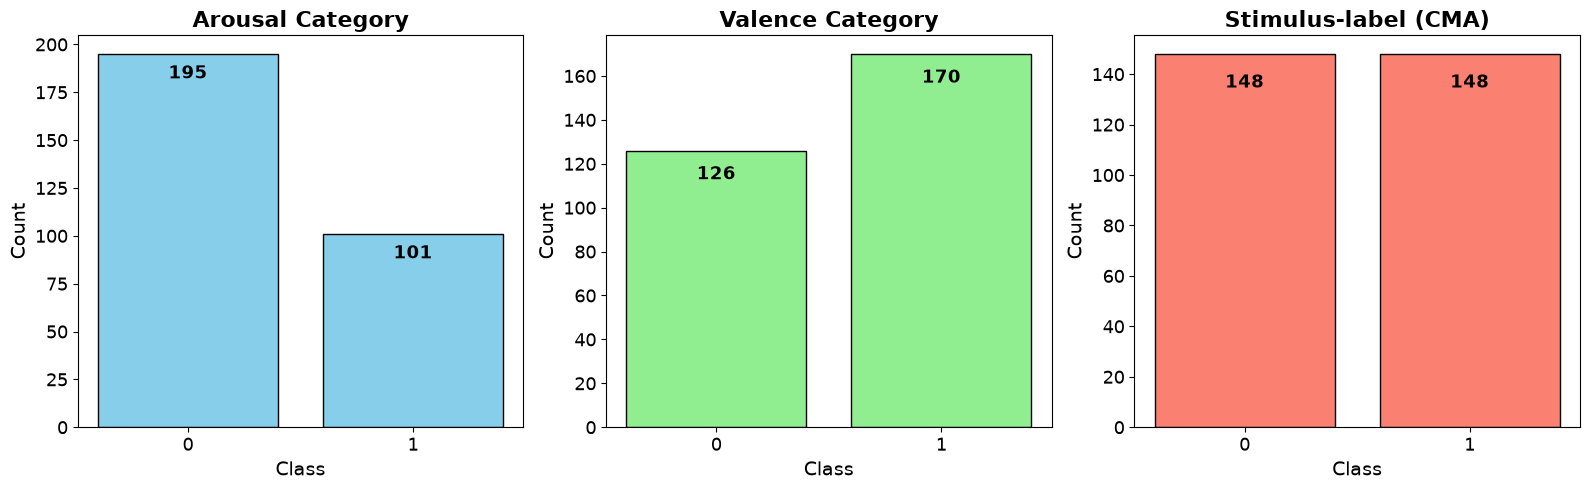

In [32]:
# ============================================================
# Load data
# ============================================================
eda_df_preprocessed_aligned = csv_read(DATA_CONFIG["eda_path"])


# ============================================================
# Plot label distributions using matplotlib
# ============================================================
cols = ["arousal_category", "valence_category", "taskwiselabel"]
titles = ["Arousal Category", "Valence Category", "Stimulus-label (CMA)"]
colors = ["skyblue", "lightgreen", "salmon"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, color in zip(axes, cols, titles, colors):

    counts = (
        eda_df_preprocessed_aligned[col]
        .value_counts()
        .sort_index()
    )

    x_labels = counts.index.astype(str)
    y_values = counts.values

    bars = ax.bar(
        x_labels,
        y_values,
        color=color,
        edgecolor="black"
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Class", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13)

    # Add count labels above bars
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h - 15,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()